1.Import the required libraries

In [25]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# dataset load karwane me help kregi

from datasets import load_dataset

2. Load Dataset

Load the dair-ai/emotion dataset dataset from hugginh Face https://huggingface.co/datasets/dair-ai/emotion

In [26]:
emotion_dataset = load_dataset("dair-ai/emotion")
train_text = emotion_dataset['train']['text']

train_label = emotion_dataset['train']['label']
train_label
test_text = emotion_dataset['test']['text']

test_label = emotion_dataset['test']['label']


In [27]:
label_names = emotion_dataset['train'].features['label'].names

df_train = pd.DataFrame(
    {
        'text' : train_text,  #train_label
        'label' : [label_names[i] for i in train_label]
}

    )

df_test = pd.DataFrame(
    {
      'text' : test_text,
      'label' :[label_names[i] for i in test_label]
    }
)

In [28]:
df_test.head()

,text,label
0,im feeling rather rotten so im not very ambiti...,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i do...,sadness
3,i left with my bouquet of red and yellow tulip...,joy
4,i was feeling a little vain when i did this one,sadness


In [29]:
label_names = emotion_dataset['train'].features['label'].names


In [30]:
train_label

Column([0, 0, 3, 2, 3])

In [31]:
for i in train_label:
  print(label_names[i])

Streaming output truncated to the last 5000 lines.
sadness
sadness
anger
fear
love
joy
anger
sadness
sadness
joy
fear
joy
fear
love
love
anger
anger
sadness
fear
sadness
sadness
surprise
love
joy
joy
love
sadness
joy
joy
fear
sadness
anger
anger
sadness
love
fear
fear
anger
anger
joy
sadness
sadness
joy
joy
fear
sadness
joy
love
fear
anger
sadness
joy
anger
surprise
fear
joy
joy
love
fear
sadness
joy
anger
fear
anger
sadness
sadness
sadness
anger
sadness
fear
joy
anger
anger
sadness
fear
joy
anger
fear
sadness
joy
fear
joy
love
anger
fear
fear
fear
fear
joy
anger
anger
sadness
joy
sadness
joy
sadness
sadness
joy
sadness
fear
fear
joy
sadness
joy
sadness
joy
fear
anger
sadness
joy
anger
joy
joy
sadness
joy
joy
anger
anger
joy
joy
joy
sadness
joy
joy
joy
anger
anger
joy
love
joy
love
joy
joy
joy
sadness
joy
sadness
surprise
sadness
anger
anger
anger
fear
fear
joy
fear
fear
joy
anger
joy
joy
joy
love
joy
fear
sadness
sadness
surprise
sadness
sadness
anger
joy
love
fear
joy
anger
joy
surpr

3.Exloratory Data Analysis (EDA)

visualize class distribution across the 6 emotion label

<Axes: xlabel='label', ylabel='count'>

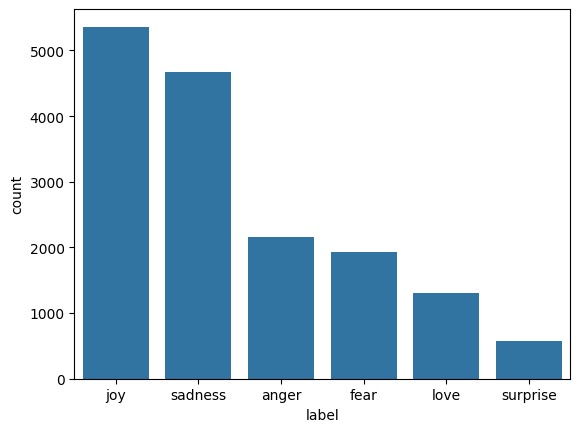

In [32]:
sns.countplot(x='label', data =df_train, order = df_train['label'].value_counts().index)


In [33]:
df_train

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger


4.Data Preprocessing

tokenize text, pad sequences to max length 50, and covert labels to numpy


In [34]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000

tokenizer = Tokenizer(num_words = max_words, oov_token='<unk>')
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
#train_sequence

test_sequence = tokenizer.texts_to_sequences(df_test['text'])
#test_sequence

padded_train_sequence = pad_sequences(train_sequence, maxlen=50, padding='post',truncating= 'post')

padded_test_sequence = pad_sequences(test_sequence, maxlen=50, padding='post',truncating= 'post')

#padded_train_sequence
#padded_train_sequence

train_labels = np.array(train_label)
test_labels = np.array(test_label)
train_labels

num_classes  = len(np.unique(train_label))
num_classes

print(f"Vocabulary Size: {len(tokenizer.word_index)}")
print(f"Max Sentence Length: {padded_train_sequence.shape[1]}")

Vocabulary Size: 15213
Max Sentence Length: 50


5.Shared Training Utilities

compute balanced class weights to handle dataset skew and
setup early stopping


In [35]:
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight(
classes=np.unique(train_labels),
y=train_labels,
class_weight = 'balanced',
)

class_weights_dict = dict(enumerate(class_weights))
class_weights_dict



{0: np.float64(0.5715102157451064),
 1: np.float64(0.49732686808404825),
 2: np.float64(2.044989775051125),
 3: np.float64(1.2351397251814111),
 4: np.float64(1.3766993632765445),
 5: np.float64(4.662004662004662)}

In [36]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor = 'val_loss',
    patience = 3,
    restore_best_weights = True
)


6. Phase 1 - Plain Foundational Models

Train plain(non-directional) Simple RNN, Standard LSTM, and Standard GRU models.

6.1 Model 1- Simple RNN

Plain unrolled Recurrent Neural Network.

1.   List item
2.   List item



In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout, LSTM, GRU

rnn_model = Sequential([

    Embedding(input_dim=max_words, output_dim =128, input_length = 50),

    SimpleRNN(units=128),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax')  # output layer
])

rnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',metrics=['accuracy'])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [44]:
rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size = 32,
    validation_split = 0.2,
    class_weight = class_weights_dict,
    callbacks = [early_stopping]
)

rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequence, test_labels)
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 33ms/step - accuracy: 0.1564 - loss: 1.8208 - val_accuracy: 0.1970 - val_loss: 1.7895
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step - accuracy: 0.1700 - loss: 1.7878 - val_accuracy: 0.2050 - val_loss: 1.7688
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 39ms/step - accuracy: 0.1723 - loss: 1.7794 - val_accuracy: 0.0905 - val_loss: 1.7967
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 37ms/step - accuracy: 0.1545 - loss: 1.9166 - val_accuracy: 0.1375 - val_loss: 1.8146
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.1368 - loss: 1.8532 - val_accuracy: 0.2170 - val_loss: 1.7767
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2050 - loss: 1.7688
RNN Loss: 1.7687716484069824
RNN Accuracy: 0.20499999821186066


6.2 Model 2 - Standaed LSTM

plain stacked long short -term memory network

In [46]:
lstm_model = Sequential([

    Embedding(input_dim=max_words, output_dim =128, input_length = 50),

    LSTM(units=128,return_sequences = True),
    Dropout(0.5),
    LSTM(units=64),
    Dense(units=num_classes, activation='softmax')  # output layer
])

lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',metrics=['accuracy'])


lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size = 32,
   # validation_split = 0.2,
    class_weight = class_weights_dict,
    callbacks = [early_stopping]
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels)
print(f"lstm Loss: {lstm_loss}")
print(f"lstm Accuracy: {lstm_accuracy}")


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 65s 123ms/step - accuracy: 0.1349 - loss: 1.7935 - val_accuracy: 0.3480 - val_loss: 1.7903
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 61s 123ms/step - accuracy: 0.1592 - loss: 1.7928 - val_accuracy: 0.2920 - val_loss: 1.7855
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 62s 123ms/step - accuracy: 0.1593 - loss: 1.8032 - val_accuracy: 0.3465 - val_loss: 1.7410
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 82s 123ms/step - accuracy: 0.1404 - loss: 1.7973 - val_accuracy: 0.1125 - val_loss: 1.7847
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 60s 120ms/step - accuracy: 0.1452 - loss: 1.7967 - val_accuracy: 0.1125 - val_loss: 1.7743
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 61s 122ms/step - accuracy: 0.1315 - loss: 1.7970 - val_accuracy: 0.0330 - val_loss: 1.8078
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.3465 - loss: 1.7410
lstm Loss: 1.7409553527832031
lstm Accuracy: 0.3465000092983246


6.3 model 3 - GRU Model



In [47]:
gru_model = Sequential([

    Embedding(input_dim=max_words, output_dim =128, input_length = 50),

    LSTM(units=128,return_sequences = True),
    Dropout(0.5),
    LSTM(units=64),
    Dense(units=num_classes, activation='softmax')  # output layer
])

gru_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',metrics=['accuracy'])


gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size = 32,
   # validation_split = 0.2,
    class_weight = class_weights_dict,
    callbacks = [early_stopping]
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_labels)
print(f"gru Loss: {gru_loss}")
print(f"gru Accuracy: {gru_accuracy}")


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 66s 123ms/step - accuracy: 0.1198 - loss: 1.7941 - val_accuracy: 0.2495 - val_loss: 1.7799
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 83s 127ms/step - accuracy: 0.2126 - loss: 1.7388 - val_accuracy: 0.1455 - val_loss: 1.7179
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 61s 121ms/step - accuracy: 0.2690 - loss: 1.6321 - val_accuracy: 0.3940 - val_loss: 1.6298
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 63s 126ms/step - accuracy: 0.2793 - loss: 1.5173 - val_accuracy: 0.1880 - val_loss: 1.4542
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 62s 124ms/step - accuracy: 0.3066 - loss: 1.3266 - val_accuracy: 0.4525 - val_loss: 1.3846
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 60s 120ms/step - accuracy: 0.3131 - loss: 1.2725 - val_accuracy: 0.2430 - val_loss: 1.4582
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 62s 123ms/step - accuracy: 0.3046 - loss: 1.2420 - val_accuracy: 0.2425 - val_loss: 1.3870
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 60s 121ms/step - accuracy: 0.3180 - loss: 1

In [50]:
result_df = pd.DataFrame({
    'Model' : ['RNN', 'LSTM', 'GRU'],
    'Test Loss' : [rnn_loss, lstm_loss, gru_loss],
    'Test Accuracy' : [rnn_accuracy, lstm_accuracy, gru_accuracy],

    }).sort_values(by='Test Accuracy', ascending = False)

result_df

,Model,Test Loss,Test Accuracy
2,GRU,1.384599,0.4525
1,LSTM,1.740955,0.3465
0,RNN,1.768772,0.2050


7. Phase 2 - Adavanced Bidirectional GRU

Enhance GRU with Bidirectional layers, 300D embeddings, and 0.5 dropout regularization

7.1 Model 4 - Advanced Stacked Bidirectional GRU


In [55]:
from  tensorflow.keras.layers import Bidirectional
BiGRU = Sequential([
    Embedding(input_dim = max_words, output_dim=300, input_length=50),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes, activation= 'softmax')  #output Layer
    #why i used num_classes in output layer and what will i get from this.
])

BiGRU.compile(optimizer='adam', loss= 'sparse_categorical_crossentropy', metrics=['accuracy'])
BiGRU.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_18 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_8 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_9 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [58]:
BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size = 32,
    class_weight = class_weights_dict,
    callbacks = [early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 156s 297ms/step - accuracy: 0.5604 - loss: 1.0474 - val_accuracy: 0.8640 - val_loss: 0.4706
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 206s 305ms/step - accuracy: 0.9157 - loss: 0.2485 - val_accuracy: 0.9220 - val_loss: 0.1975
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 154s 309ms/step - accuracy: 0.9439 - loss: 0.1567 - val_accuracy: 0.9160 - val_loss: 0.2446
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 147s 294ms/step - accuracy: 0.9566 - loss: 0.1183 - val_accuracy: 0.9250 - val_loss: 0.2361
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 147s 294ms/step - accuracy: 0.9680 - loss: 0.0896 - val_accuracy: 0.9205 - val_loss: 0.2868


In [61]:
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequence,test_labels)
print(f"BiGRU Loss: {BiGRU_loss}")
print(f"BiGRU Accuracy: {BiGRU_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - accuracy: 0.9220 - loss: 0.1975
BiGRU Loss: 0.19745312631130219
BiGRU Accuracy: 0.921999990940094


63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 163ms/step


<Axes: >

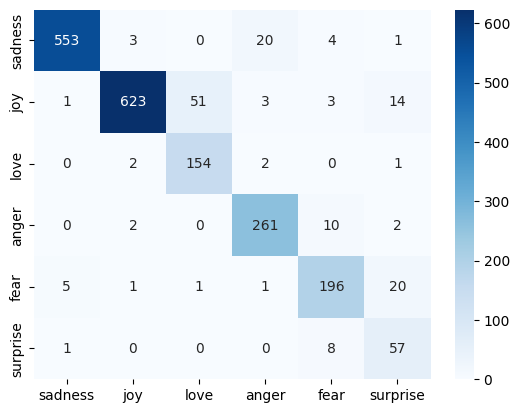

In [62]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequence),axis=1)

sns.heatmap(confusion_matrix(test_label, BiGRU_predictions), annot=True, fmt='d', cmap = 'Blues', xticklabels=label_names, yticklabels=label_names)

In [67]:
sample_texts = [
"I can't believe how happy I am right now, this is amazing!",
"I feel so alone and hopeless today.",
"I am furious that they cancelled the trip at the last minute.",
"I feel terrified when walking down dark alleyways alone.",
"I was shocked and completely surprised by the unexpected gift!"
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis = 1)

sample_predictions

for i in range(len(sample_texts)):
  print(f'Text: {sample_texts[i]}\nPredicted Emotion: {label_names[sample_predictions[i]]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
Text: I can't believe how happy I am right now, this is amazing!
Predicted Emotion: surprise
Text: I feel so alone and hopeless today.
Predicted Emotion: sadness
Text: I am furious that they cancelled the trip at the last minute.
Predicted Emotion: anger
Text: I feel terrified when walking down dark alleyways alone.
Predicted Emotion: fear
Text: I was shocked and completely surprised by the unexpected gift!
Predicted Emotion: surprise


10. Save Model & Tokenizer

Export trained model and tokenizer artifacts for api deployment.

In [71]:
import os
import pickle

model_dir = 'Artifacts'

os.makedirs(model_dir, exist_ok = True)  # yh folder hai jiske andar sari exported file aane wali hai

#Save our BiGRU Model
BiGRU.save(os.path.join(model_dir,'BiGRU_model.keras'))


# Save the tokenizer model
with open (os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
  pickle.dump(tokenizer, file)